Первые строки:
   variable
0        16
1        15
2        12
3         8
4        17

Размер данных:
Строк: 49
Столбцов: 1

Типы данных:
variable    int64
dtype: object

Пропущенные значения:
variable    0
dtype: int64

Числовые столбцы:
['variable']

Описательная статистика:
          count   mean   std  min   25%   50%   75%   max  Размах   IQR
variable   49.0  21.06  9.58  5.0  15.0  20.0  26.0  60.0    55.0  11.0

Количество выбросов:
variable: 1

Тест Шапиро—Уилка:
variable: W = 0.9168, p-value = 0.0020
  Распределение статистически отличается от нормального.


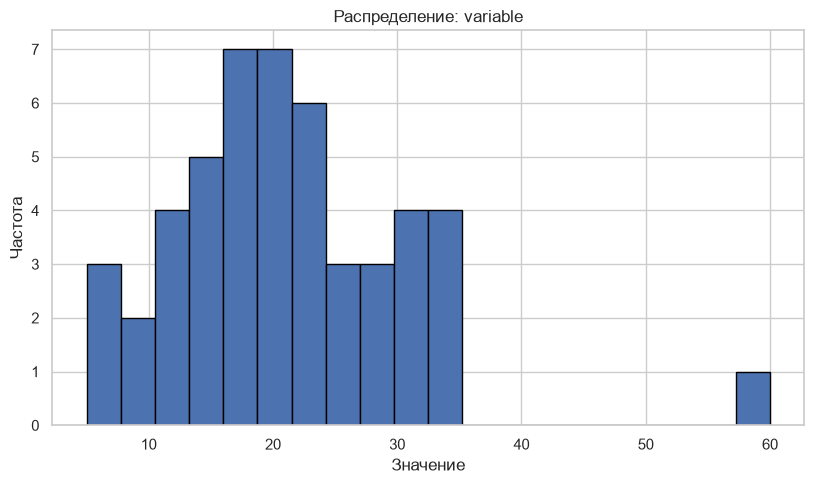

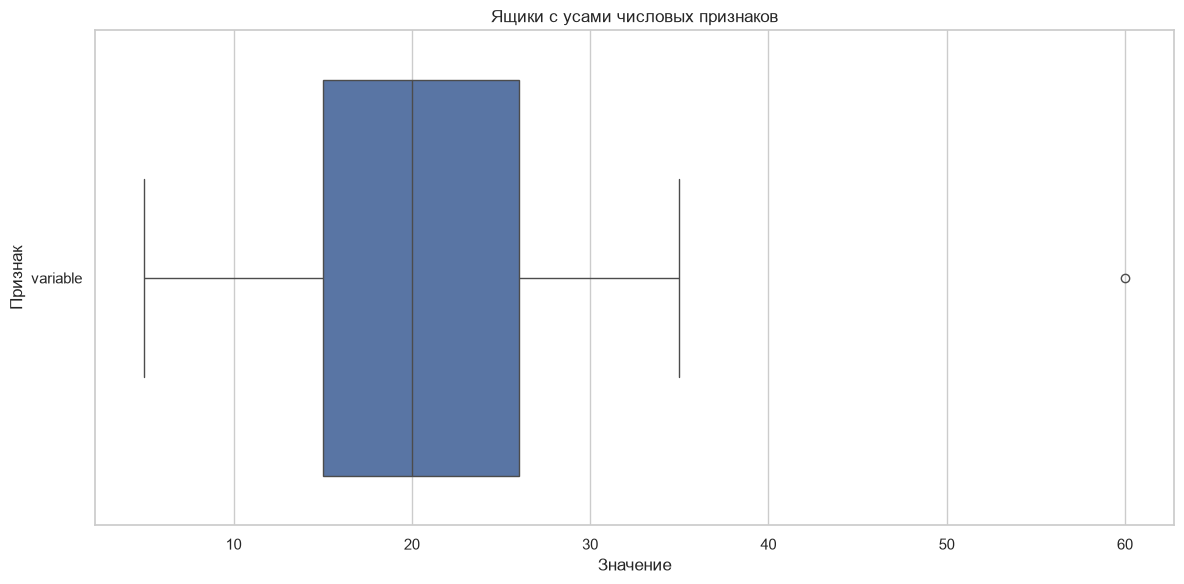

In [1]:
import math

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro


# 1. Загрузка данных
data = pd.read_csv("data_test.csv")

# 2. Предварительный анализ
print("Первые строки:")
print(data.head())

print("\nРазмер данных:")
print(f"Строк: {data.shape[0]}")
print(f"Столбцов: {data.shape[1]}")

print("\nТипы данных:")
print(data.dtypes)

# 3. Пропущенные значения
missing = data.isnull().sum()

print("\nПропущенные значения:")
print(missing)

# Удаляем строки с пропусками только в числовых столбцах
numeric_data = data.select_dtypes(include="number").copy()
numeric_data = numeric_data.dropna()

if numeric_data.empty:
    raise ValueError("В файле нет числовых данных для анализа.")

print("\nЧисловые столбцы:")
print(numeric_data.columns.tolist())

# 4. Описательная статистика
statistics = numeric_data.describe().T

statistics["Размах"] = (
    statistics["max"] - statistics["min"]
)

statistics["IQR"] = (
    statistics["75%"] - statistics["25%"]
)

print("\nОписательная статистика:")
print(statistics.round(2))

# 5. Поиск выбросов методом IQR
outliers = {}

for column in numeric_data.columns:
    q1 = numeric_data[column].quantile(0.25)
    q3 = numeric_data[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    values = numeric_data[
        (numeric_data[column] < lower_bound) |
        (numeric_data[column] > upper_bound)
    ][column]

    outliers[column] = len(values)

print("\nКоличество выбросов:")
for column, count in outliers.items():
    print(f"{column}: {count}")

# 6. Проверка нормальности распределения
print("\nТест Шапиро—Уилка:")

for column in numeric_data.columns:
    values = numeric_data[column]

    # Для выборок больше 5000 берём случайные 5000 значений
    if len(values) > 5000:
        values = values.sample(5000, random_state=42)

    statistic, p_value = shapiro(values)

    print(
        f"{column}: "
        f"W = {statistic:.4f}, "
        f"p-value = {p_value:.4f}"
    )

    if p_value >= 0.05:
        print("  Распределение можно считать близким к нормальному.")
    else:
        print("  Распределение статистически отличается от нормального.")

# 7. Визуализация
sns.set_theme(style="whitegrid")

columns = numeric_data.columns
n = len(columns)
rows = math.ceil(n / 2)

fig, axes = plt.subplots(
    rows,
    2,
    figsize=(16, 5 * rows)
)

# Приводим axes к одномерному массиву
axes = axes.ravel()

for i, column in enumerate(columns):
    axes[i].hist(
        numeric_data[column],
        bins=20,
        edgecolor="black"
    )

    axes[i].set_title(f"Распределение: {column}")
    axes[i].set_xlabel("Значение")
    axes[i].set_ylabel("Частота")

# Удаляем пустые графики
for i in range(n, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# 8. Ящики с усами
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=numeric_data,
    orient="h"
)

plt.title("Ящики с усами числовых признаков")
plt.xlabel("Значение")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()


Структура данных:
   variable
0        16
1        15
2        12
3         8
4        17

Пропущенные значения:
variable    0
dtype: int64

Описание данных:
        variable
count  49.000000
mean   21.061224
std     9.577335
min     5.000000
25%    15.000000
50%    20.000000
75%    26.000000
max    60.000000



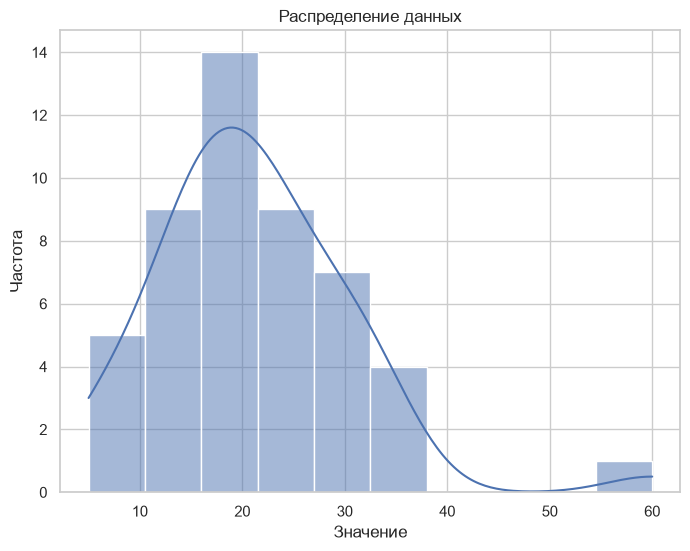

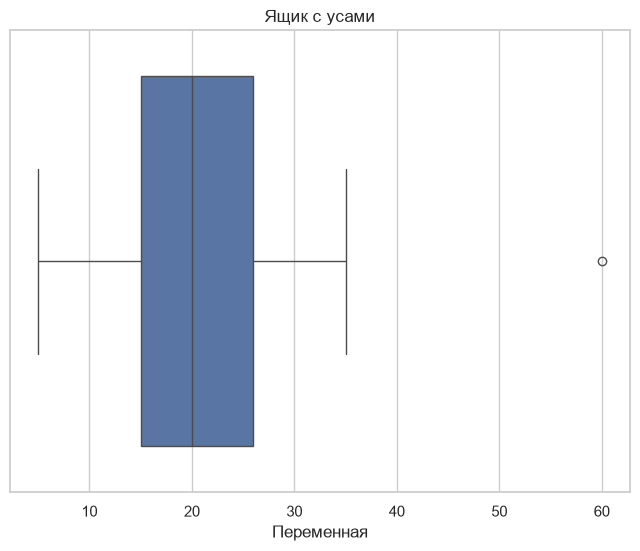

Тест нормальности:
Статистика теста: 0.9167791960824303
p-значение: 0.002034995493166612



In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

# Загрузка данных из файла CSV
data = pd.read_csv('data_test.csv')

# Предварительный анализ данных
# Изучение структуры данных
print("Структура данных:")
print(data.head())
print()

# Оценка пропущенных значений
print("Пропущенные значения:")
print(data.isnull().sum())
print()

# Проверка аномальных значений и выбросов
print("Описание данных:")
print(data.describe())
print()

# Исследование распределения данных
# Построение гистограммы
plt.figure(figsize=(8, 6))
sns.histplot(data['variable'], kde=True)
plt.title("Распределение данных")
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.show()

# Построение ящика с усами
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['variable'])
plt.title("Ящик с усами")
plt.xlabel("Переменная")
plt.show()

# Проверка нормальности распределения
stat, p = shapiro(data['variable'])
print("Тест нормальности:")
print(f"Статистика теста: {stat}")
print(f"p-значение: {p}")
print()